[]

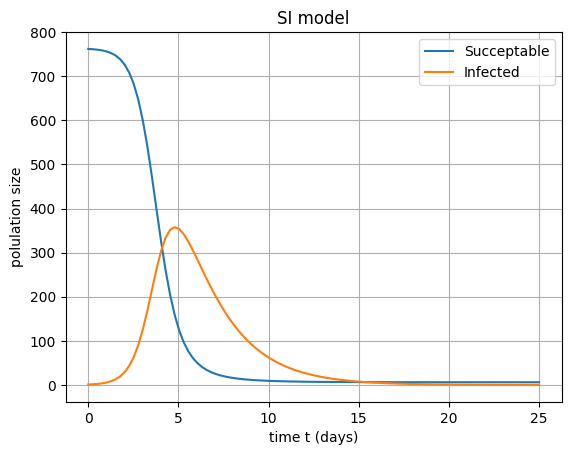

In [4]:
# SI model
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

S0=762 # initial succeptable
I0=1 # initial infected
beta=0.0028 # infection rate
gamma=0.44 # recovery rate
t=np.linspace(0,25,100)
y0=[S0,I0]

def SI_model(y0, t):
    S0, I0=y0
    dSdt=-beta*S0*I0
    dIdt=beta*S0*I0 - gamma*I0
    return dSdt, dIdt

solution=odeint(func=SI_model, y0=y0, t=t)
S=solution[:,0]
I=solution[:,1]

plt.plot(t,S, label='Succeptable')
plt.plot(t,I, label='Infected')
plt.legend()
plt.xlabel('time t (days)')
plt.ylabel('polulation size')
plt.title('SI model')
plt.grid()
plt.plot()


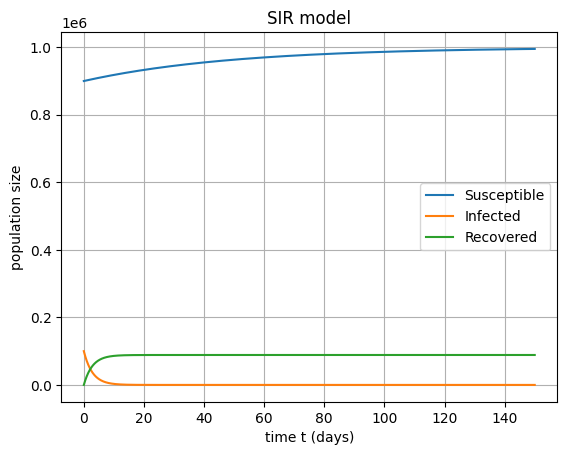

In [18]:
# for an endemic where birth and death are also involved
S0=900000
I0=100000
beta=0.000365
gamma=0.33
a=b=0.02
N=S0+I0
t=np.linspace(0,150,10000)

# Use per-capita (mass-action) transmission: beta*S*I / N
def epidemic_disease(y0, t):
    S0, I0, R0 = y0
    dSdt = b * N - (beta * S0 * I0) / N - a * S0
    dIdt = (beta * S0 * I0) / N - gamma * I0 - a * I0
    dRdt = gamma * I0 - a * I0

    return dSdt, dIdt, dRdt

# initial recovered set so S0+I0+R0 = N
R0_initial = N - S0 - I0
solution = odeint(func=epidemic_disease, y0=[S0, I0, R0_initial], t=t)
S = solution[:, 0]
I = solution[:, 1]
R = solution[:, 2]

plt.plot(t, S, label='Susceptible')
plt.plot(t, I, label='Infected')
plt.plot(t, R, label='Recovered')
plt.legend()
plt.xlabel('time t (days)')
plt.ylabel('population size')
plt.title('SIR model')
plt.grid()
plt.show()
